# MVP 1 — Audio → SD Image via CLAP Nearest-Neighbor Retrieval

**Pipeline**: audio → librosa → CLAP embedding → cosine similarity vs prompt library → SD-Turbo on MPS

No training. Zero-shot retrieval only.

In [1]:
# Cell 2 — Install (run once)
!pip install torch torchvision diffusers accelerate matplotlib transformers librosa ipd -q

^C
ERROR: Operation cancelled by user


In [2]:
# Cell 1 — Environment check
import torch, sys

print(f'Python: {sys.version}')
print(f'PyTorch: {torch.__version__}')
print(f'MPS available: {torch.backends.mps.is_available()}')

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')

Python: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
PyTorch: 2.11.0
MPS available: True
Using device: mps


/Users/aviudash/Code/classes/CS231N/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/Users/aviudash/Code/classes/CS231N/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 10.11it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of t

Time taken: 5.32 seconds


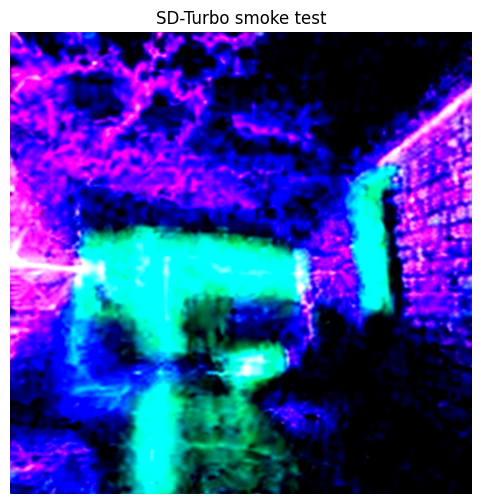

Token indices sequence length is longer than the specified maximum sequence length for this model (81 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['. neo - soul aesthetic.']
100%|██████████| 4/4 [00:03<00:00,  1.14it/s]


Time taken: 6.00 seconds


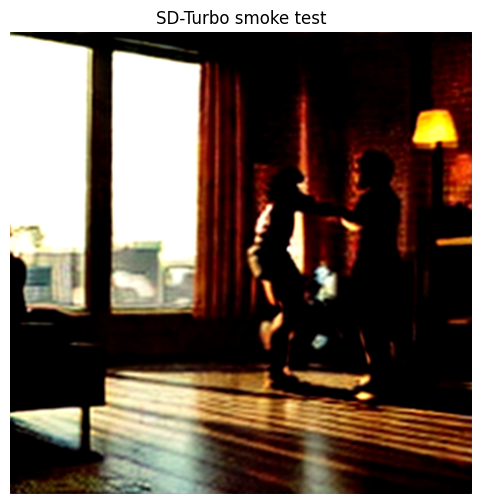

Smoke test passed.


In [3]:
# Cell 3 — SD-Turbo smoke test
# Confirms generation works before adding CLAP logic.
# First run downloads ~3GB to ~/.cache/huggingface
import torch, matplotlib.pyplot as plt
import time
from diffusers import AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained(
    'stabilityai/sd-turbo',
    torch_dtype=torch.float32,
)
pipe = pipe.to(device)
pipe.enable_attention_slicing()  # ~20% peak memory reduction on MPS

# time image generation
start_time = time.time()
image = pipe(
    'Neon-lit underground trap den, low-angle shot, thick purple and green smoke clouds drifting through cyan and magenta laser light beams, chrome and glass aesthetic, holographic graffiti on concrete walls, Bay Area skyline faintly visible through a cracked warehouse window at night, hyperrealistic digital art, cinematic lighting, 4K, vaporwave-meets-cyberpunk palette',
    num_inference_steps=4,
    guidance_scale=5.0,
).images[0]
end_time = time.time()
print(f'Time taken: {end_time - start_time:.2f} seconds')

plt.figure(figsize=(6, 6))
plt.imshow(image); plt.axis('off'); plt.title('SD-Turbo smoke test'); plt.show()

start_time = time.time()
image2 = pipe(
    'A dimly lit apartment at night, golden hour lamp glow casting warm amber light across a couple slow-dancing in a living room. Vinyl records on the shelf, city lights blurred through floor-to-ceiling windows behind them. Cinematic grain. Shallow depth of field. Muted earth tones — burnt sienna, deep burgundy, warm brown skin tones. Shot on 35mm film. Neo-soul aesthetic.',
    num_inference_steps=4,
    guidance_scale=5.0,
).images[0]
end_time = time.time()
print(f'Time taken: {end_time - start_time:.2f} seconds')

plt.figure(figsize=(6, 6))
plt.imshow(image2); plt.axis('off'); plt.title('SD-Turbo smoke test'); plt.show()

torch.mps.empty_cache()
print('Smoke test passed.')

In [4]:
# Cell 4 — CLAP setup
# CPU only: inference is ~50ms and avoids competing with SD for MPS memory
from transformers import ClapModel, ClapProcessor

clap_model = ClapModel.from_pretrained('laion/clap-htsat-fused')
clap_processor = ClapProcessor.from_pretrained('laion/clap-htsat-fused')
clap_model.eval()

print(f'CLAP loaded. Embedding dim: {clap_model.config.projection_dim}')

Loading weights: 100%|██████████| 477/477 [00:00<00:00, 7054.45it/s]


CLAP loaded. Embedding dim: 512


In [5]:
# Cell 5 — Prompt library
# Each entry has:
#   music_description — music-language text that CLAP embeds for retrieval
#   visual_prompt     — rich visual description that SD uses for generation

PROMPT_LIBRARY = [
    # Electronic / dark
    {'music_description': 'dark techno music with heavy industrial beats, distorted synthesizers, and a menacing atmosphere',
     'visual_prompt': 'a desolate industrial cityscape at night, glowing neon reflections on wet asphalt, deep purples and electric blues, dense fog, hyperrealistic',
     'tags': ['electronic', 'dark']},
    {'music_description': 'dark minimal techno with repetitive mechanical rhythms, low bass drones, and cold electronic textures',
     'visual_prompt': 'an abandoned underground bunker, flickering fluorescent light, shadows, industrial decay, monochromatic grays, photorealistic',
     'tags': ['electronic', 'dark', 'techno']},

    # Electronic / euphoric
    {'music_description': 'euphoric trance music with soaring synthesizer leads, energetic build-ups, and uplifting drops',
     'visual_prompt': 'an infinite kaleidoscopic light show, vibrant prismatic colors exploding outward, cosmic energy, ecstatic motion blur',
     'tags': ['electronic', 'euphoric', 'rave']},
    {'music_description': 'energetic house music with a driving four-on-the-floor beat, bright chord stabs, and a euphoric dancefloor atmosphere',
     'visual_prompt': 'a neon-lit dance floor from above, colorful lasers cutting through smoke, energy, celebration, synthwave aesthetic',
     'tags': ['electronic', 'euphoric', 'house']},

    # Jazz / melancholic
    {'music_description': 'melancholic jazz with a solo saxophone, slow brushed drums, upright bass, and a late-night blue mood',
     'visual_prompt': 'a lone saxophone player in a dimly lit jazz bar, warm amber light, cigarette smoke curling, rain streaking the window, impressionist oil painting',
     'tags': ['jazz', 'melancholic']},
    {'music_description': 'slow blues jazz with muted trumpet, sparse piano chords, and a lonely introspective feeling',
     'visual_prompt': 'an empty late-night diner under pale neon signs, reflections on wet pavement, solitude, Edward Hopper style',
     'tags': ['jazz', 'blues', 'melancholic']},

    # Orchestral / epic
    {'music_description': 'epic cinematic orchestral music with powerful brass, thundering timpani, sweeping strings, and a dramatic heroic theme',
     'visual_prompt': 'a vast mountainous battlefield at golden hour, thousands in silhouette, dramatic storm clouds, epic fantasy digital painting',
     'tags': ['orchestral', 'epic', 'cinematic']},
    {'music_description': 'majestic orchestral film score with full choir, soaring strings, and a grand ceremonial feeling',
     'visual_prompt': 'a colossal gothic cathedral interior flooded with golden light through stained glass, towering spires, divine atmosphere, detailed oil painting',
     'tags': ['orchestral', 'epic', 'classical']},

    # Ambient / meditative
    {'music_description': 'peaceful ambient music with slow evolving pads, gentle bells, and a serene meditative atmosphere',
     'visual_prompt': 'a serene misty Japanese garden at dawn, still reflecting pond, lotus flowers, soft pastel watercolors, peaceful silence',
     'tags': ['ambient', 'meditative']},
    {'music_description': 'deep ambient drone music with slowly shifting harmonic textures, reverberant tones, and an otherworldly floating sensation',
     'visual_prompt': 'deep ocean bioluminescent field, glowing jellyfish, soft blue light diffusing through dark water, floating weightless',
     'tags': ['ambient', 'dreamy', 'meditative']},
    {'music_description': 'minimal ambient soundscape with sparse piano notes, long reverb tails, and vast open space',
     'visual_prompt': 'a cloud sea at high altitude, mountain peaks piercing through, golden sunrise light, minimal and vast',
     'tags': ['ambient', 'spacious']},

    # Hip-hop / aggressive
    {'music_description': 'aggressive hip hop with heavy 808 bass, hard trap beats, rapid hi-hats, and intense rap vocals',
     'visual_prompt': 'urban street art explosion, graffiti murals towering over a night alley, bold primary colors, raw energy, city power',
     'tags': ['hip-hop', 'aggressive']},
    {'music_description': 'boom bap hip hop with sampled breaks, deep bass, vinyl crackle, and confident rap delivery',
     'visual_prompt': 'a rooftop cypher under city skyline at night, spotlight, raw concrete, spray paint, dynamic composition',
     'tags': ['hip-hop', 'rap']},

    # Pop / bright
    {'music_description': 'bright upbeat pop music with catchy synth hooks, driving drums, and a cheerful joyful energy',
     'visual_prompt': 'a candy-colored dreamscape, pastel balloons, confetti shower, golden sunshine, joyful energy, playful illustration style',
     'tags': ['pop', 'bright', 'happy']},
    {'music_description': 'tropical pop music with summery guitar riffs, light percussion, and a carefree vacation atmosphere',
     'visual_prompt': 'a vibrant tropical beach at midday, turquoise water, white sand, vivid parasols, carefree summer vacation',
     'tags': ['pop', 'bright', 'upbeat']},

    # Metal / intense
    {'music_description': 'heavy metal with distorted down-tuned guitars, double bass drum blasts, aggressive vocals, and an intense crushing energy',
     'visual_prompt': 'a volcanic eruption at night, rivers of molten lava, lightning splitting the sky, dramatic chiaroscuro, raw elemental fury',
     'tags': ['metal', 'intense']},
    {'music_description': 'death metal with fast tremolo picking, blastbeat drums, guttural growling, and a dark chaotic intensity',
     'visual_prompt': 'a hellish forge, molten iron, sparks cascading, dark fantasy, intense heat and shadow',
     'tags': ['metal', 'heavy', 'intense']},

    # Folk / warm
    {'music_description': 'acoustic folk music with fingerpicked guitar, warm vocals, and a nostalgic rural storytelling feeling',
     'visual_prompt': 'rolling green Irish countryside at sunset, wildflowers, dry stone walls, golden hour light, rustic cottage, warm watercolor',
     'tags': ['folk', 'warm']},
    {'music_description': 'indie folk music with acoustic guitar, banjo, communal group singing, and a cozy campfire warmth',
     'visual_prompt': 'a bonfire gathering in an autumn forest clearing, warm orange light, people in plaid, falling leaves, nostalgic',
     'tags': ['folk', 'acoustic', 'warm']},

    # Classical / serene
    {'music_description': 'elegant classical piano music with gentle dynamics, refined phrasing, and a serene contemplative mood',
     'visual_prompt': 'a grand marble concert hall interior, ornate gilded architecture, soft candlelight from chandeliers, Baroque painting style',
     'tags': ['classical', 'serene']},
    {'music_description': 'slow classical string quartet with delicate bowing, soft harmonics, and a quiet wintry stillness',
     'visual_prompt': 'a snow-covered European square at dawn, still fountains, pigeons, soft grey-blue morning light, impressionist',
     'tags': ['classical', 'serene', 'winter']},

    # Funk / groove
    {'music_description': 'funky disco music with a tight rhythm section, slap bass, wah guitar, brass stabs, and a danceable groove',
     'visual_prompt': 'a 1970s disco ball exploding light across a packed dance floor, warm golds and oranges, joyful chaos, vintage photograph',
     'tags': ['funk', 'groove', 'disco']},

    # Reggae / chill
    {'music_description': 'laid-back reggae music with offbeat guitar skank, deep bass, and a relaxed sun-soaked Caribbean feel',
     'visual_prompt': 'a hammock strung between palms on a Caribbean beach, late afternoon light, gentle surf, red and gold sunset sky, relaxed',
     'tags': ['reggae', 'chill']},

    # Experimental / drone
    {'music_description': 'experimental drone music with sustained tones, microtonal clusters, and a disorienting abstract soundscape',
     'visual_prompt': 'an endless geometric corridor warping into infinity, monochrome gradients, spatial disorientation, digital glitch art',
     'tags': ['drone', 'experimental', 'abstract']},
    {'music_description': 'psychedelic experimental music with swirling effects, pitch-shifted textures, and a hallucinatory intensity',
     'visual_prompt': 'a fractured crystalline landscape, shards of light refracting endlessly, surrealist hyperspace, otherworldly',
     'tags': ['experimental', 'psychedelic']},
]

print(f'{len(PROMPT_LIBRARY)} prompts loaded.')


25 prompts loaded.


In [6]:
# Cell 6 — Precompute text embeddings
# Embed music_description (not visual_prompt) — CLAP's text encoder understands music language.
import torch.nn.functional as F

def _to_tensor(out):
    return out if isinstance(out, torch.Tensor) else out.pooler_output

music_descriptions = [p['music_description'] for p in PROMPT_LIBRARY]

with torch.no_grad():
    inputs = clap_processor(text=music_descriptions, return_tensors='pt', padding=True)
    text_embeddings = F.normalize(_to_tensor(clap_model.get_text_features(**inputs)), dim=-1)

print(f'Text embeddings: {text_embeddings.shape}')


Text embeddings: torch.Size([25, 512])


In [7]:
# Cell 7 — Audio loading + CLAP audio embedding
import librosa

AUDIO_PATH = '/Users/aviudash/Music/Avi DJ Pool/D\'Angelo Brown Sugar Edit.mp3'  # <-- set this
CLAP_SAMPLE_RATE = 48000
MAX_DURATION_SEC = 10

audio_array, _ = librosa.load(AUDIO_PATH, sr=CLAP_SAMPLE_RATE, mono=True)
# load a random 10 second clip in the middle of the song
audio_array = audio_array[int(len(audio_array)/2 - MAX_DURATION_SEC * CLAP_SAMPLE_RATE/2):int(len(audio_array)/2 + MAX_DURATION_SEC * CLAP_SAMPLE_RATE/2)]
print(f'Audio: {len(audio_array)/CLAP_SAMPLE_RATE:.1f}s @ {CLAP_SAMPLE_RATE}Hz')

with torch.no_grad():
    inputs = clap_processor(audio=[audio_array], sampling_rate=CLAP_SAMPLE_RATE, return_tensors='pt')
    audio_embedding = F.normalize(_to_tensor(clap_model.get_audio_features(**inputs)), dim=-1)

print(f'Audio embedding: {audio_embedding.shape}')


Audio: 10.0s @ 48000Hz
Audio embedding: torch.Size([1, 512])


In [8]:
# play the 10 second clip
from IPython.display import Audio
Audio(audio_array, rate=CLAP_SAMPLE_RATE)


In [9]:
# Cell 8 — Nearest-neighbor retrieval

similarities = (audio_embedding @ text_embeddings.T).squeeze(0)  # [N]

top_k = 3
top_indices = similarities.argsort(descending=True)[:top_k]

print('Top matches:')
for rank, idx in enumerate(top_indices):
    score = similarities[idx].item()
    entry = PROMPT_LIBRARY[idx]
    print(f'  {rank+1}. [{score:.3f}] {entry["tags"]}')
    print(f'     music: {entry["music_description"][:80]}...')

best_idx = top_indices[0].item()
matched_prompt = PROMPT_LIBRARY[best_idx]['visual_prompt']
print(f'\nVisual prompt: {matched_prompt[:80]}...')


Top matches:
  1. [0.444] ['hip-hop', 'aggressive']
     music: aggressive hip hop with heavy 808 bass, hard trap beats, rapid hi-hats, and inte...
  2. [0.439] ['funk', 'groove', 'disco']
     music: funky disco music with a tight rhythm section, slap bass, wah guitar, brass stab...
  3. [0.309] ['electronic', 'euphoric', 'house']
     music: energetic house music with a driving four-on-the-floor beat, bright chord stabs,...

Visual prompt: urban street art explosion, graffiti murals towering over a night alley, bold pr...


Prompt: urban street art explosion, graffiti murals towering over a night alley, bold primary colors, raw energy, city power, simple, minimalistic



100%|██████████| 4/4 [00:03<00:00,  1.31it/s]


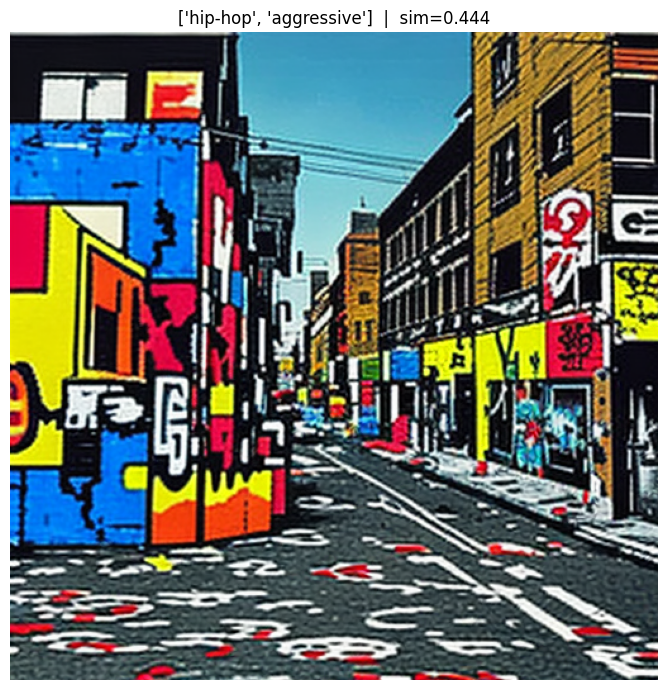

In [10]:
# Cell 9 — Style-anchored SD-Turbo generation
# STYLE_ANCHOR = 'digital painting, highly detailed, cinematic composition, artstation quality'
STYLE_ANCHOR = 'simple, minimalistic'

final_prompt = f'{matched_prompt}, {STYLE_ANCHOR}'
print(f'Prompt: {final_prompt}\n')

image = pipe(
    final_prompt,
    num_inference_steps=4,
    guidance_scale=0.0,
).images[0]

plt.figure(figsize=(7, 7))
plt.imshow(image); plt.axis('off')
plt.title(f"{PROMPT_LIBRARY[best_idx]['tags']}  |  sim={similarities[best_idx]:.3f}")
plt.tight_layout(); plt.show()

torch.mps.empty_cache()


In [11]:
# Cell 10 — Batch sweep (optional)
# Fill AUDIO_CLIPS with (label, path) tuples for a qualitative evaluation grid.

AUDIO_CLIPS = [
    # ('Dark Techno', 'clips/techno.mp3'),
    # ('Jazz Ballad',  'clips/jazz.mp3'),
    # ('Folk Guitar',  'clips/folk.mp3'),
    # ('Metal',        'clips/metal.mp3'),
    # ('Ambient',      'clips/ambient.mp3'),
]

if not AUDIO_CLIPS:
    print('Add paths to AUDIO_CLIPS to run the batch sweep.')
else:
    n = len(AUDIO_CLIPS)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1: axes = [axes]

    for ax, (label, path) in zip(axes, AUDIO_CLIPS):
        arr, _ = librosa.load(path, sr=CLAP_SAMPLE_RATE, mono=True)
        arr = arr[:MAX_DURATION_SEC * CLAP_SAMPLE_RATE]

        with torch.no_grad():
            inp = clap_processor(audios=[arr], sampling_rate=CLAP_SAMPLE_RATE, return_tensors='pt')
            sims = (emb @ text_embeddings.T).squeeze(0)
            best = sims.argmax().item()

        img = pipe(
            f"{PROMPT_LIBRARY[best]['visual_prompt']}, {STYLE_ANCHOR}",
            num_inference_steps=4, guidance_scale=0.0,
        ).images[0]
        torch.mps.empty_cache()

        ax.imshow(img); ax.axis('off')
        ax.set_title(f"{label}\n{PROMPT_LIBRARY[best]['tags']}  [{sims[best]:.2f}]", fontsize=9)

    plt.tight_layout(); plt.show()

Add paths to AUDIO_CLIPS to run the batch sweep.
